Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Zonas urbanas: 271
Densidad media: 1803.78 arboles/km2
Temp media: 36.58 C
                            OLS Regression Results                            
Dep. Variable:             Temp_media   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                   0.06709
Date:                Thu, 06 Aug 2026   Prob (F-statistic):              0.796
Time:                        07:47:02   Log-Likelihood:                -707.64
No. Observations:                 271   AIC:                             1419.
Df Residuals:                     269   BIC:                             1426.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
      

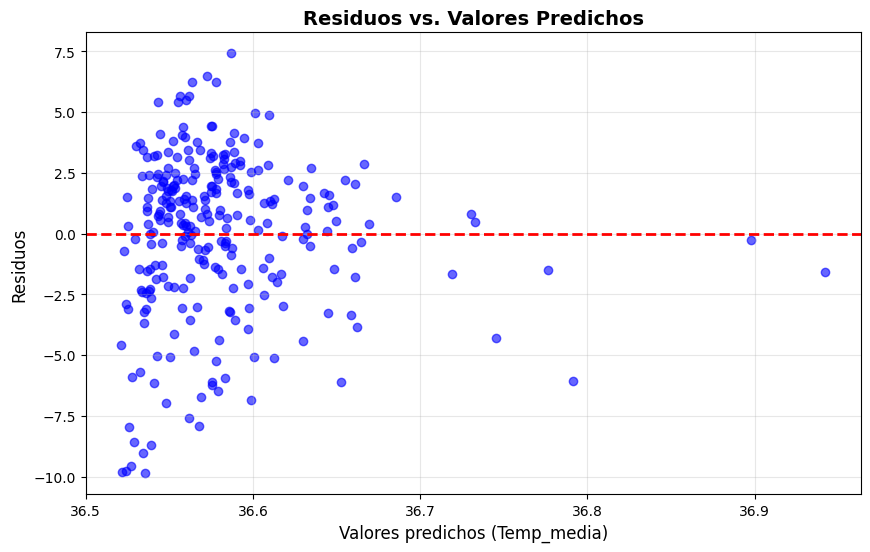


Shapiro-Wilk (normalidad): p = 0.0000
Los residuos NO siguen una distribucion normal

Residuos - Media: -0.0000, Std: 3.3007
Rango: [-9.8706, 7.4129]


In [ ]:
import pandas as pd
import geopandas as gpd
import statsmodels.api as sm
import scipy.stats as stats
import matplotlib.pyplot as plt
import os
from google.colab import drive

# ============================================================
# 1. MONTAR DRIVE Y RUTAS
# ============================================================
drive.mount('/content/drive')
ruta_base = "/content/drive/MyDrive/Analisis_Geoespacial/Proyecto_Curso/Datos/Datos_procesados/"

ruta_zonas = os.path.join(ruta_base, "Zonas_Medellin.gpkg")
ruta_temp = os.path.join(ruta_base, "Temperatura_por_zona.csv")
ruta_arboles = os.path.join(ruta_base, "Arboles_Activos_Medellin_TODOS.gpkg")

# ============================================================
# 2. CARGAR DATOS
# ============================================================
zonas = gpd.read_file(ruta_zonas)
df_temp = pd.read_csv(ruta_temp)

try:
    arboles = gpd.read_file(ruta_arboles)
except MemoryError:
    arboles = gpd.read_file(ruta_arboles, rows=50000)

# ============================================================
# 3. UNION ESPACIAL Y CONTEO DE ARBOLES
# ============================================================
if arboles.crs != zonas.crs:
    arboles = arboles.to_crs(zonas.crs)

arboles_en_zonas = gpd.sjoin(arboles, zonas, how='inner', predicate='within')
columna_zona = 'ID' if 'ID' in arboles_en_zonas.columns else 'index_right'

conteo_arboles = arboles_en_zonas.groupby(columna_zona).size().reset_index(name='num_arboles')
conteo_arboles = conteo_arboles.rename(columns={columna_zona: 'ID'})

# ============================================================
# 4. TEMPERATURA PROMEDIO POR ZONA
# ============================================================
temp_promedio = df_temp.groupby('ID')['Temp_media'].mean().reset_index()

# ============================================================
# 5. UNIR DATOS Y CALCULAR DENSIDAD
# ============================================================
zonas_temp = zonas.merge(temp_promedio, left_index=True, right_on='ID', how='left')
zonas_temp = zonas_temp.merge(conteo_arboles, on='ID', how='left')
zonas_temp['num_arboles'] = zonas_temp['num_arboles'].fillna(0).astype(int)

zonas_temp['area_km2'] = zonas_temp.geometry.area / 1_000_000
zonas_temp['densidad_arboles'] = zonas_temp['num_arboles'] / zonas_temp['area_km2']

# ============================================================
# 6. FILTRAR ZONAS URBANAS
# ============================================================
zonas_urbano = zonas_temp[zonas_temp['Tipo'] == 'Urbano'].copy()

print(f"Zonas urbanas: {len(zonas_urbano)}")
print(f"Densidad media: {zonas_urbano['densidad_arboles'].mean():.2f} arboles/km2")
print(f"Temp media: {zonas_urbano['Temp_media'].mean():.2f} C")

# ============================================================
# 7. MODELO GAUSSIANO
# ============================================================
y = zonas_urbano['Temp_media']
X = sm.add_constant(zonas_urbano[['densidad_arboles']])
modelo = sm.OLS(y, X).fit()

# ============================================================
# 8. RESULTADOS DEL MODELO
# ============================================================
print(modelo.summary())

intercepto = modelo.params['const']
coef_densidad = modelo.params['densidad_arboles']
r2 = modelo.rsquared
p_densidad = modelo.pvalues['densidad_arboles']

print(f"\nEcuacion: Temp_media = {intercepto:.2f} + ({coef_densidad:.4f}) * densidad_arboles")
print(f"R2 = {r2:.4f}")
print(f"p-valor (densidad) = {p_densidad:.4f}")

if p_densidad < 0.05:
    if coef_densidad < 0:
        print("Efecto SIGNIFICATIVO: mas arboles = menor temperatura")
    else:
        print("Efecto SIGNIFICATIVO: mas arboles = mayor temperatura")
else:
    print("Efecto NO significativo (p >= 0.05)")

# ============================================================
# 9. DIAGNOSTICO DE RESIDUOS
# ============================================================
y_pred = modelo.predict(X)
residuals = y - y_pred
zonas_urbano['residuales'] = residuals

# Grafico: Residuos vs Predichos
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6, color='blue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Valores predichos (Temp_media)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title('Residuos vs. Valores Predichos', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(ruta_base, "Residuos_vs_Predichos.png"), dpi=300, bbox_inches='tight')
plt.show()

# Prueba de normalidad
if len(residuals) < 5000:
    shapiro_stat, shapiro_p = stats.shapiro(residuals)
    print(f"\nShapiro-Wilk (normalidad): p = {shapiro_p:.4f}")
    if shapiro_p > 0.05:
        print("Los residuos siguen una distribucion normal")
    else:
        print("Los residuos NO siguen una distribucion normal")

# Estadisticas de residuos
print(f"\nResiduos - Media: {residuals.mean():.4f}, Std: {residuals.std():.4f}")
print(f"Rango: [{residuals.min():.4f}, {residuals.max():.4f}]")

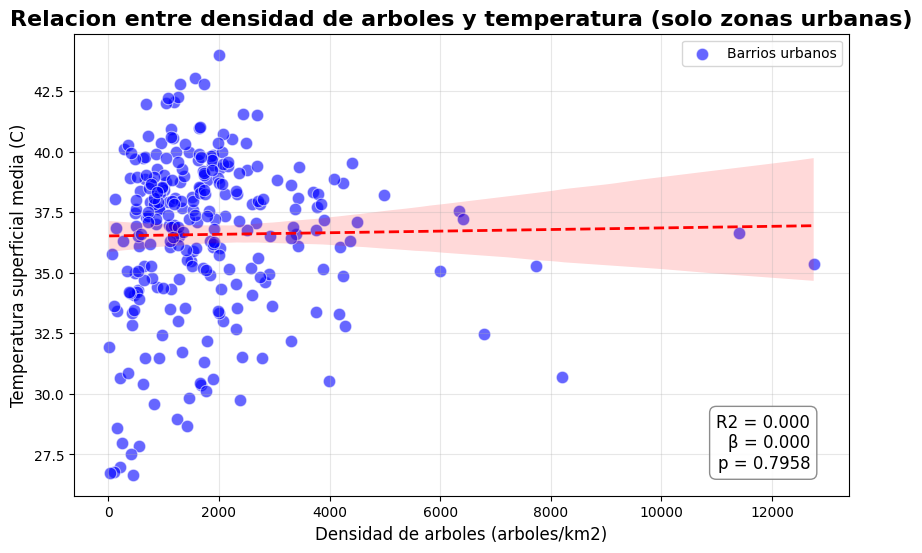

Grafico guardado en: /content/drive/MyDrive/Analisis_Geoespacial/Proyecto_Curso/Datos/Datos_procesados/Relacion_Densidad_Temperatura.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ============================================================
# GRAFICO DE DISPERSION: DENSIDAD DE ARBOLES VS TEMPERATURA
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Graficar puntos de datos (barrios urbanos)
sns.scatterplot(data=zonas_urbano, x='densidad_arboles', y='Temp_media',
                alpha=0.6, color='blue', s=80, label='Barrios urbanos')

# Graficar linea de regresion
sns.regplot(data=zonas_urbano, x='densidad_arboles', y='Temp_media',
            scatter=False, color='red', line_kws={'linewidth': 2, 'linestyle': '--'})

# Configurar titulos y etiquetas
ax.set_title('Relacion entre densidad de arboles y temperatura (solo zonas urbanas)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Densidad de arboles (arboles/km2)', fontsize=12)
ax.set_ylabel('Temperatura superficial media (C)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Extraer metricas del modelo
intercepto = modelo.params['const']
coef_densidad = modelo.params['densidad_arboles']
r2 = modelo.rsquared
p_densidad = modelo.pvalues['densidad_arboles']

# Agregar caja con metricas (R2, beta, p-valor)
texto_metricas = f'R2 = {r2:.3f}\nβ = {coef_densidad:.3f}\np = {p_densidad:.4f}'
ax.text(0.95, 0.05, texto_metricas,
        transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='gray'),
        fontsize=12, ha='right', va='bottom')

# Guardar grafico
ruta_grafico = os.path.join(ruta_base, "Relacion_Densidad_Temperatura.png")
plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
plt.show()

print(f"Grafico guardado en: {ruta_grafico}")

In [ ]:
import pandas as pd
import geopandas as gpd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
import os
from google.colab import drive

# ============================================================
# 1. MONTAR DRIVE Y RUTAS
# ============================================================
drive.mount('/content/drive')
ruta_base = "/content/drive/MyDrive/Analisis_Geoespacial/Proyecto_Curso/Datos/Datos_procesados/"

ruta_zonas = os.path.join(ruta_base, "Zonas_Medellin.gpkg")
ruta_temp = os.path.join(ruta_base, "Temperatura_por_zona.csv")
ruta_arboles = os.path.join(ruta_base, "Arboles_Activos_Medellin_TODOS.gpkg")

# ============================================================
# 2. CARGAR DATOS
# ============================================================
zonas = gpd.read_file(ruta_zonas)
df_temp = pd.read_csv(ruta_temp)

try:
    arboles = gpd.read_file(ruta_arboles)
except MemoryError:
    arboles = gpd.read_file(ruta_arboles, rows=50000)

# ============================================================
# 3. UNION ESPACIAL Y CONTEO DE ARBOLES
# ============================================================
if arboles.crs != zonas.crs:
    arboles = arboles.to_crs(zonas.crs)

arboles_en_zonas = gpd.sjoin(arboles, zonas, how='inner', predicate='within')
columna_zona = 'ID' if 'ID' in arboles_en_zonas.columns else 'index_right'

conteo_arboles = arboles_en_zonas.groupby(columna_zona).size().reset_index(name='num_arboles')
conteo_arboles = conteo_arboles.rename(columns={columna_zona: 'ID'})

# ============================================================
# 4. TEMPERATURA PROMEDIO POR ZONA
# ============================================================
temp_promedio = df_temp.groupby('ID')['Temp_media'].mean().reset_index()

# ============================================================
# 5. UNIR DATOS Y CALCULAR AREA
# ============================================================
zonas_temp = zonas.merge(temp_promedio, left_index=True, right_on='ID', how='left')
zonas_temp = zonas_temp.merge(conteo_arboles, on='ID', how='left')
zonas_temp['num_arboles'] = zonas_temp['num_arboles'].fillna(0).astype(int)
zonas_temp['area_km2'] = zonas_temp.geometry.area / 1_000_000

# ============================================================
# 6. FILTRAR ZONAS URBANAS
# ============================================================
zonas_urbano = zonas_temp[zonas_temp['Tipo'] == 'Urbano'].copy()

print(f"Zonas urbanas: {len(zonas_urbano)}")
print(f"Arboles totales: {zonas_urbano['num_arboles'].sum():,}")
print(f"Area total: {zonas_urbano['area_km2'].sum():.2f} km2")
print(f"Temp media: {zonas_urbano['Temp_media'].mean():.2f} C")

# ============================================================
# 7. MODELO DE POISSON
# ============================================================
# Variable dependiente: conteo de arboles
y = zonas_urbano['num_arboles']

# Variable independiente: temperatura
X = zonas_urbano[['Temp_media']]

# Añadir constante
X = sm.add_constant(X)

# Ajustar modelo de Poisson
modelo_poisson = sm.GLM(y, X, family=sm.families.Poisson()).fit()

# Mostrar resultados
print(modelo_poisson.summary())

# ============================================================
# 8. EXTRAER METRICAS
# ============================================================
intercepto = modelo_poisson.params['const']
coef_temp = modelo_poisson.params['Temp_media']
p_temp = modelo_poisson.pvalues['Temp_media']
devianza = modelo_poisson.deviance
df_resid = modelo_poisson.df_resid

print(f"\nEcuacion del modelo:")
print(f"log(num_arboles) = {intercepto:.4f} + ({coef_temp:.4f}) * Temp_media")
print(f"\nInterpretacion:")
print(f"   Por cada aumento de 1 C en temperatura, el log-conteo de arboles cambia en {coef_temp:.4f}")
print(f"   El conteo esperado de arboles se multiplica por {np.exp(coef_temp):.4f} por cada 1 C de aumento")
print(f"\nMetricas:")
print(f"   p-valor (temperatura): {p_temp:.4f}")
print(f"   Devianza: {devianza:.2f}")
print(f"   Grados de libertad residuales: {df_resid}")

if p_temp < 0.05:
    if coef_temp < 0:
        print("   Efecto SIGNIFICATIVO: mayor temperatura = menor numero de arboles")
    else:
        print("   Efecto SIGNIFICATIVO: mayor temperatura = mayor numero de arboles")
else:
    print("   Efecto NO significativo (p >= 0.05)")

# ============================================================
# 9. MODELO CON OFFSET (AREA COMO EXPOSICION)
# ============================================================
# Ajustar modelo con offset (log del area)
X_offset = zonas_urbano[['Temp_media']]
X_offset = sm.add_constant(X_offset)

# Offset = log(area_km2)
offset = np.log(zonas_urbano['area_km2'])

modelo_offset = sm.GLM(y, X_offset,
                       family=sm.families.Poisson(),
                       offset=offset).fit()

print(modelo_offset.summary())

intercepto_offset = modelo_offset.params['const']
coef_temp_offset = modelo_offset.params['Temp_media']
p_temp_offset = modelo_offset.pvalues['Temp_media']

print(f"\nEcuacion del modelo (con offset):")
print(f"log(num_arboles / area_km2) = {intercepto_offset:.4f} + ({coef_temp_offset:.4f}) * Temp_media")
print(f"   Esto equivale a: log(densidad_arboles) = {intercepto_offset:.4f} + ({coef_temp_offset:.4f}) * Temp_media")
print(f"\nInterpretacion:")
print(f"   Por cada aumento de 1 C en temperatura, la densidad esperada de arboles se multiplica por {np.exp(coef_temp_offset):.4f}")
print(f"\nMetricas:")
print(f"   p-valor (temperatura): {p_temp_offset:.4f}")

if p_temp_offset < 0.05:
    if coef_temp_offset < 0:
        print("   Efecto SIGNIFICATIVO: mayor temperatura = menor densidad de arboles")
    else:
        print("   Efecto SIGNIFICATIVO: mayor temperatura = mayor densidad de arboles")
else:
    print("   Efecto NO significativo (p >= 0.05)")

# ============================================================
# 10. COMPARACION ENTRE MODELOS
# ============================================================
print(f"Modelo Gaussiano (OLS):")
print(f"   R2 = {modelo.rsquared:.4f}")

print(f"\nModelo Poisson (conteos):")
print(f"   Devianza: {modelo_poisson.deviance:.2f}")
print(f"   AIC: {modelo_poisson.aic:.2f}")

print(f"\nModelo Poisson con offset (densidad):")
print(f"   Devianza: {modelo_offset.deviance:.2f}")
print(f"   AIC: {modelo_offset.aic:.2f}")

if modelo_offset.aic < modelo_poisson.aic:
    print("   El modelo con offset (densidad) es mejor segun AIC")
else:
    print("   El modelo de conteos (Poisson) es mejor segun AIC")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Zonas urbanas: 271
Arboles totales: 197,536
Area total: 101.23 km2
Temp media: 36.58 C
                 Generalized Linear Model Regression Results                  
Dep. Variable:            num_arboles   No. Observations:                  271
Model:                            GLM   Df Residuals:                      269
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -94785.
Date:                Thu, 06 Aug 2026   Deviance:                   1.8744e+05
Time:                        07:54:47   Pearson chi2:                 2.55e+05
No. Iterations:                     5   Pseudo R-squ. (CS):             0.9741
Covariance Type:            nonrobust                                    

/tmp/ipykernel_7330/2241100471.py:22: RuntimeWarning: overflow encountered in exp
  y_pred_poisson = np.exp(modelo_poisson.predict(X_pred))
/tmp/ipykernel_7330/2241100471.py:40: RuntimeWarning: overflow encountered in exp
  densidad_pred = np.exp(modelo_offset.predict(X_pred))


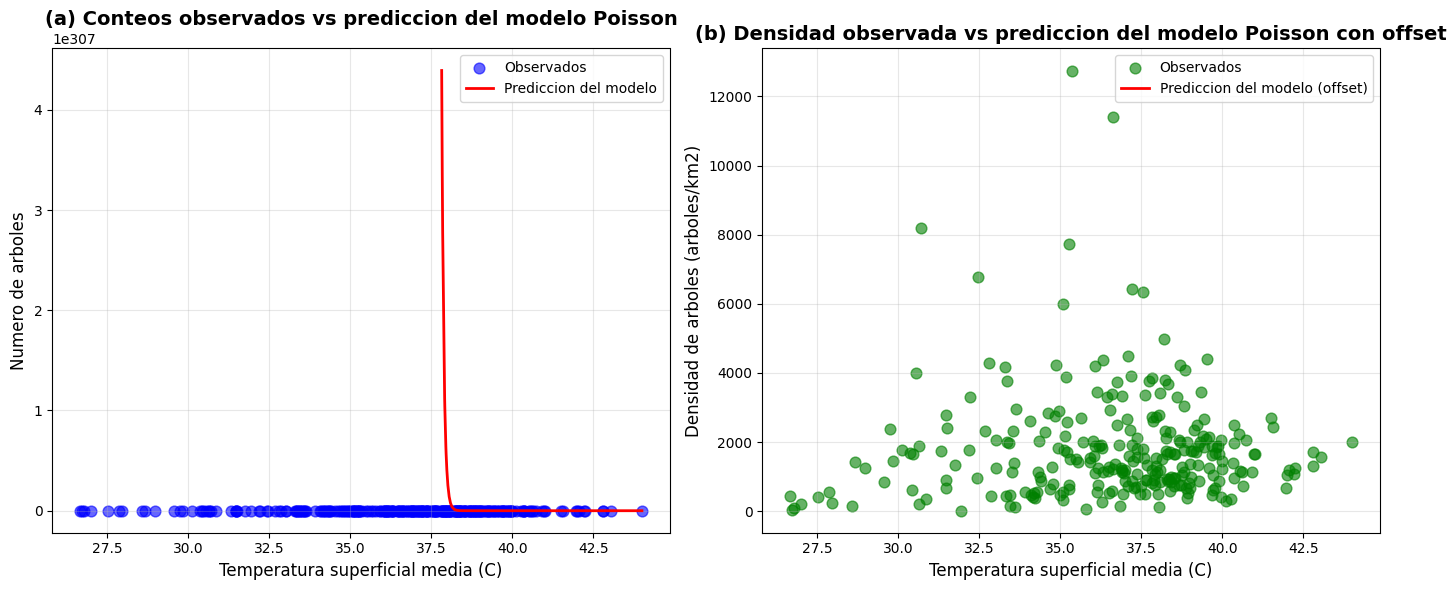

Grafico del modelo Poisson guardado en: /content/drive/MyDrive/Analisis_Geoespacial/Proyecto_Curso/Datos/Datos_procesados/Modelo_Poisson_Conteos.png

Residuales calculados para 271 observaciones


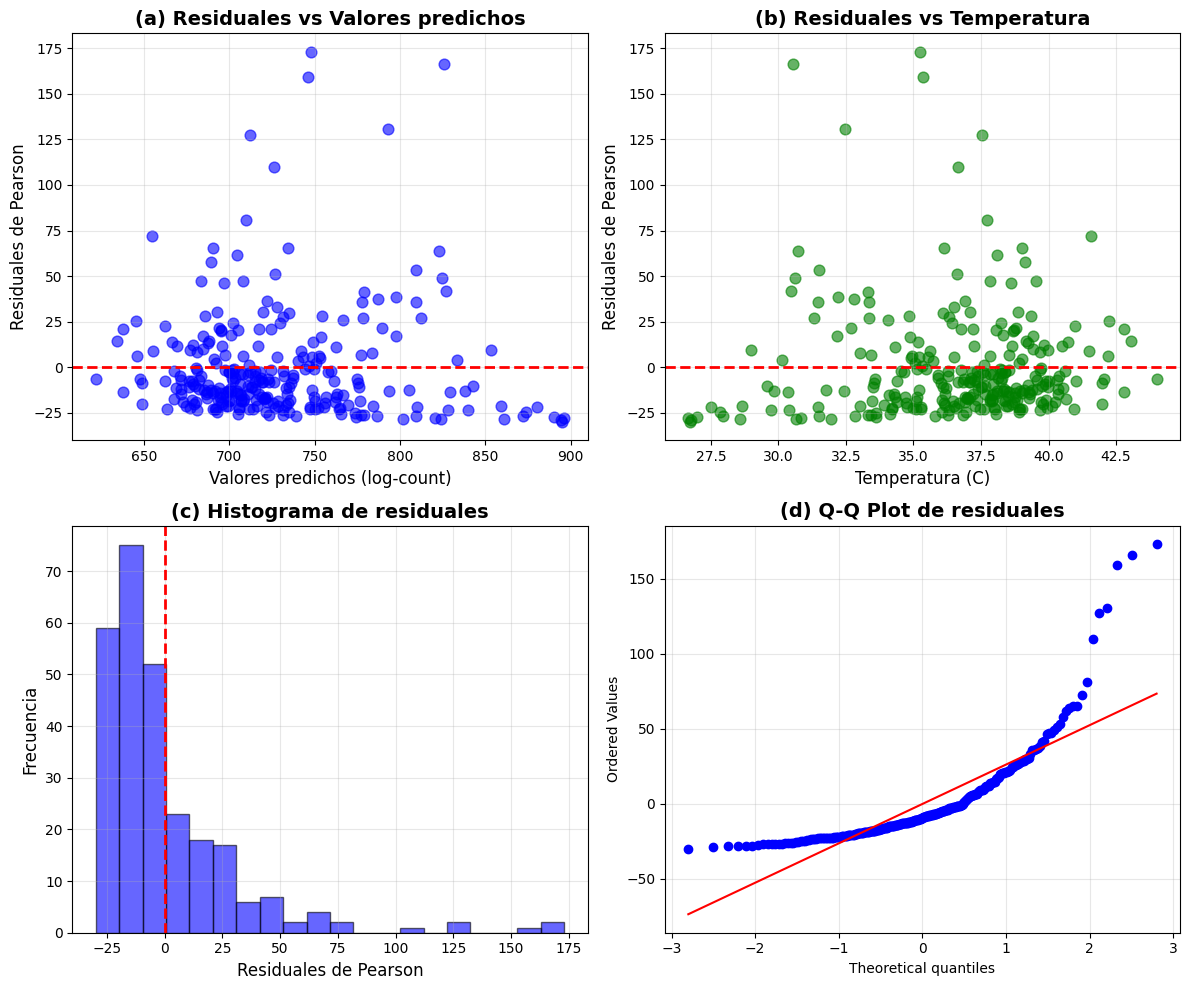

Grafico de residuales guardado en: /content/drive/MyDrive/Analisis_Geoespacial/Proyecto_Curso/Datos/Datos_procesados/Residuales_Poisson.png

ESTADISTICAS DE RESIDUALES - MODELO POISSON
Residuales de Pearson:
   Media: -0.0020
   Desviacion: 30.7521
   Minimo: -29.7836
   Maximo: 172.9609

Residuales de Devianza:
   Media: -4.1399
   Desviacion: 26.0196
   Minimo: -41.6989
   Maximo: 111.1517

PRUEBA DE SOBREDISPERSION
Ratio de sobredispersion (Pearson chi2 / df): 949.2088
   El modelo presenta SOBREDISPERSION (ratio > 1)
   Se recomienda usar un modelo Binomial Negativo
Ratio de Devianza / df: 696.8044
   La devianza sugiere sobredispersion


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import scipy.stats as stats

# ============================================================
# 1. GRAFICO DE DISPERSION: TEMPERATURA VS CONTEOS (POISSON)
# ============================================================

# Crear figura con dos paneles
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel (a): Conteos observados vs predichos
ax1 = axes[0]
ax1.scatter(zonas_urbano['Temp_media'], zonas_urbano['num_arboles'],
            alpha=0.6, color='blue', s=60, label='Observados')

# Ordenar para la curva de prediccion
temp_sorted = np.sort(zonas_urbano['Temp_media'])
X_pred = sm.add_constant(temp_sorted)
y_pred_poisson = np.exp(modelo_poisson.predict(X_pred))

ax1.plot(temp_sorted, y_pred_poisson, color='red', linewidth=2,
         label='Prediccion del modelo')
ax1.set_xlabel('Temperatura superficial media (C)', fontsize=12)
ax1.set_ylabel('Numero de arboles', fontsize=12)
ax1.set_title('(a) Conteos observados vs prediccion del modelo Poisson',
              fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel (b): Densidad observada vs predichos (con offset)
ax2 = axes[1]
ax2.scatter(zonas_urbano['Temp_media'],
            zonas_urbano['num_arboles'] / zonas_urbano['area_km2'],
            alpha=0.6, color='green', s=60, label='Observados')

# Prediccion de densidad (con offset)
densidad_pred = np.exp(modelo_offset.predict(X_pred))
ax2.plot(temp_sorted, densidad_pred, color='red', linewidth=2,
         label='Prediccion del modelo (offset)')
ax2.set_xlabel('Temperatura superficial media (C)', fontsize=12)
ax2.set_ylabel('Densidad de arboles (arboles/km2)', fontsize=12)
ax2.set_title('(b) Densidad observada vs prediccion del modelo Poisson con offset',
              fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# Guardar figura
ruta_grafico_poisson = os.path.join(ruta_base, "Modelo_Poisson_Conteos.png")
plt.savefig(ruta_grafico_poisson, dpi=300, bbox_inches='tight')
plt.show()
print(f"Grafico del modelo Poisson guardado en: {ruta_grafico_poisson}")

# ============================================================
# 2. CALCULO DE RESIDUALES DEL MODELO POISSON
# ============================================================

# Residuales de Pearson
pearson_residuals = modelo_poisson.resid_pearson

# Residuales de Devianza
deviance_residuals = modelo_poisson.resid_deviance

# Residuales de respuesta (observado - predicho)
response_residuals = modelo_poisson.resid_response

# Añadir al DataFrame
zonas_urbano['pearson_resid'] = pearson_residuals
zonas_urbano['deviance_resid'] = deviance_residuals
zonas_urbano['response_resid'] = response_residuals

print(f"\nResiduales calculados para {len(zonas_urbano)} observaciones")

# ============================================================
# 3. GRAFICO DE DIAGNOSTICO DE RESIDUALES (POISSON)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Grafico 1: Residuales vs Valores predichos
ax1 = axes[0, 0]
ax1.scatter(modelo_poisson.fittedvalues, pearson_residuals,
            alpha=0.6, color='blue', s=60)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Valores predichos (log-count)', fontsize=12)
ax1.set_ylabel('Residuales de Pearson', fontsize=12)
ax1.set_title('(a) Residuales vs Valores predichos', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Grafico 2: Residuales vs Temperatura
ax2 = axes[0, 1]
ax2.scatter(zonas_urbano['Temp_media'], pearson_residuals,
            alpha=0.6, color='green', s=60)
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Temperatura (C)', fontsize=12)
ax2.set_ylabel('Residuales de Pearson', fontsize=12)
ax2.set_title('(b) Residuales vs Temperatura', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Grafico 3: Distribucion de residuales (histograma)
ax3 = axes[1, 0]
ax3.hist(pearson_residuals, bins=20, color='blue', alpha=0.6, edgecolor='black')
ax3.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('Residuales de Pearson', fontsize=12)
ax3.set_ylabel('Frecuencia', fontsize=12)
ax3.set_title('(c) Histograma de residuales', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Grafico 4: Q-Q plot para normalidad
ax4 = axes[1, 1]
stats.probplot(pearson_residuals, dist="norm", plot=ax4)
ax4.set_title('(d) Q-Q Plot de residuales', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()

# Guardar grafico de residuales
ruta_grafico_resid = os.path.join(ruta_base, "Residuales_Poisson.png")
plt.savefig(ruta_grafico_resid, dpi=300, bbox_inches='tight')
plt.show()
print(f"Grafico de residuales guardado en: {ruta_grafico_resid}")

# ============================================================
# 4. ESTADISTICAS DE RESIDUALES
# ============================================================
print("\n" + "=" * 60)
print("ESTADISTICAS DE RESIDUALES - MODELO POISSON")
print("=" * 60)

print(f"Residuales de Pearson:")
print(f"   Media: {pearson_residuals.mean():.4f}")
print(f"   Desviacion: {pearson_residuals.std():.4f}")
print(f"   Minimo: {pearson_residuals.min():.4f}")
print(f"   Maximo: {pearson_residuals.max():.4f}")

print(f"\nResiduales de Devianza:")
print(f"   Media: {deviance_residuals.mean():.4f}")
print(f"   Desviacion: {deviance_residuals.std():.4f}")
print(f"   Minimo: {deviance_residuals.min():.4f}")
print(f"   Maximo: {deviance_residuals.max():.4f}")

# ============================================================
# 5. PRUEBA DE SOBREDISPERSION
# ============================================================
print("\n" + "=" * 60)
print("PRUEBA DE SOBREDISPERSION")
print("=" * 60)

# Ratio de sobredispersion
pearson_chi2 = modelo_poisson.pearson_chi2
dispersion_ratio = pearson_chi2 / modelo_poisson.df_resid
print(f"Ratio de sobredispersion (Pearson chi2 / df): {dispersion_ratio:.4f}")

if dispersion_ratio > 1:
    print("   El modelo presenta SOBREDISPERSION (ratio > 1)")
    print("   Se recomienda usar un modelo Binomial Negativo")
else:
    print("   No hay evidencia de sobredispersion (ratio <= 1)")
    print("   El modelo Poisson es adecuado")

# Prueba de sobredispersion de Cameron y Trivedi (simplificada)
# Comparar Devianza vs grados de libertad
deviance_ratio = modelo_poisson.deviance / modelo_poisson.df_resid
print(f"Ratio de Devianza / df: {deviance_ratio:.4f}")

if deviance_ratio > 2:
    print("   La devianza sugiere sobredispersion")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Zonas urbanas: 271
Arboles totales: 197,536
Area total: 101.23 km2
Temp media: 36.58 C
Densidad media: 1803.78 arboles/km2

MODELO BINOMIAL NEGATIVO - CONTEOS DE ARBOLES POR ZONA
                 Generalized Linear Model Regression Results                  
Dep. Variable:            num_arboles   No. Observations:                  271
Model:                            GLM   Df Residuals:                      269
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2056.7
Date:                Thu, 06 Aug 2026   Deviance:                       305.32
Time:                        08:04:00   Pearson chi2:                     339.
No. Iterations:                     7   Pseudo R-squ. (CS): 

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
/tmp/ipykernel_7330/46869432.py:225: RuntimeWarning: overflow encountered in exp
  y_pred_nb = np.exp(modelo_nb_alpha.predict(X_pred))
/tmp/ipykernel_7330/46869432.py:240: RuntimeWarning: overflow encountered in exp
  densidad_pred_nb = np.exp(modelo_nb_offset.predict(X_pred))
/usr/local/lib/python3.12/dist-packages/matplotlib/axes/_base.py:3024: RuntimeWarning: overflow encountered in scalar add
  x0, x1 = inverse_trans.transform([x0t - delta, x1t + delta])


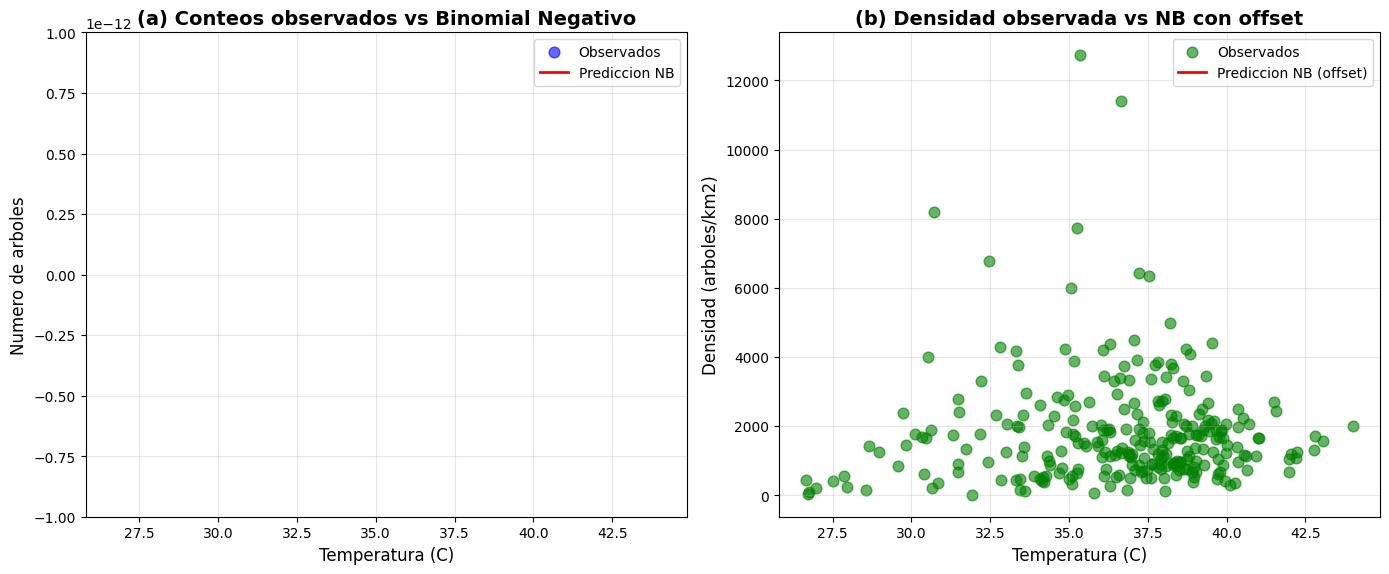


Figura guardada en: /content/drive/MyDrive/Analisis_Geoespacial/Proyecto_Curso/Datos/Datos_procesados/Modelo_Binomial_Negativo.png


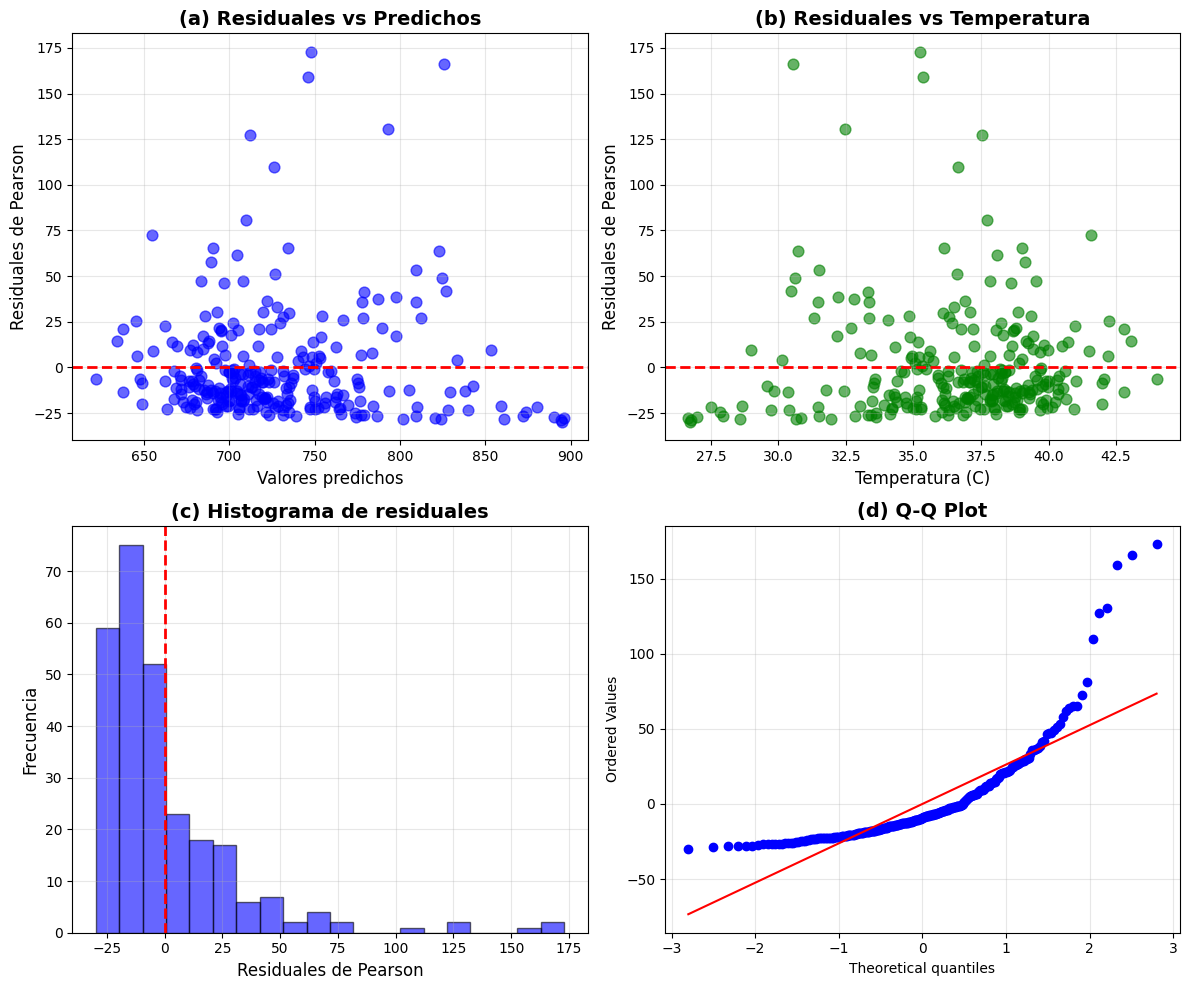

Residuales guardados en: /content/drive/MyDrive/Analisis_Geoespacial/Proyecto_Curso/Datos/Datos_procesados/Residuales_Binomial_Negativo.png

ESTADISTICAS DE RESIDUALES
Media: -0.0020
Desviacion: 30.7354
Minimo: -29.7648
Maximo: 172.8670


In [ ]:
import pandas as pd
import geopandas as gpd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import scipy.stats as stats
from google.colab import drive

# ============================================================
# 1. MONTAR DRIVE Y RUTAS
# ============================================================
drive.mount('/content/drive')
ruta_base = "/content/drive/MyDrive/Analisis_Geoespacial/Proyecto_Curso/Datos/Datos_procesados/"

ruta_zonas = os.path.join(ruta_base, "Zonas_Medellin.gpkg")
ruta_temp = os.path.join(ruta_base, "Temperatura_por_zona.csv")
ruta_arboles = os.path.join(ruta_base, "Arboles_Activos_Medellin_TODOS.gpkg")

# ============================================================
# 2. CARGAR DATOS
# ============================================================
zonas = gpd.read_file(ruta_zonas)
df_temp = pd.read_csv(ruta_temp)

try:
    arboles = gpd.read_file(ruta_arboles)
except MemoryError:
    arboles = gpd.read_file(ruta_arboles, rows=50000)

# ============================================================
# 3. UNION ESPACIAL Y CONTEO DE ARBOLES
# ============================================================
if arboles.crs != zonas.crs:
    arboles = arboles.to_crs(zonas.crs)

arboles_en_zonas = gpd.sjoin(arboles, zonas, how='inner', predicate='within')
columna_zona = 'ID' if 'ID' in arboles_en_zonas.columns else 'index_right'

conteo_arboles = arboles_en_zonas.groupby(columna_zona).size().reset_index(name='num_arboles')
conteo_arboles = conteo_arboles.rename(columns={columna_zona: 'ID'})

# ============================================================
# 4. TEMPERATURA PROMEDIO POR ZONA
# ============================================================
temp_promedio = df_temp.groupby('ID')['Temp_media'].mean().reset_index()

# ============================================================
# 5. UNIR DATOS Y CALCULAR AREA
# ============================================================
zonas_temp = zonas.merge(temp_promedio, left_index=True, right_on='ID', how='left')
zonas_temp = zonas_temp.merge(conteo_arboles, on='ID', how='left')
zonas_temp['num_arboles'] = zonas_temp['num_arboles'].fillna(0).astype(int)
zonas_temp['area_km2'] = zonas_temp.geometry.area / 1_000_000
zonas_temp['densidad_arboles'] = zonas_temp['num_arboles'] / zonas_temp['area_km2']

# ============================================================
# 6. FILTRAR ZONAS URBANAS
# ============================================================
zonas_urbano = zonas_temp[zonas_temp['Tipo'] == 'Urbano'].copy()

print(f"Zonas urbanas: {len(zonas_urbano)}")
print(f"Arboles totales: {zonas_urbano['num_arboles'].sum():,}")
print(f"Area total: {zonas_urbano['area_km2'].sum():.2f} km2")
print(f"Temp media: {zonas_urbano['Temp_media'].mean():.2f} C")
print(f"Densidad media: {zonas_urbano['densidad_arboles'].mean():.2f} arboles/km2")

# ============================================================
# 7. MODELO POISSON (para comparacion)
# ============================================================
y = zonas_urbano['num_arboles']
X = sm.add_constant(zonas_urbano[['Temp_media']])

modelo_poisson = sm.GLM(y, X, family=sm.families.Poisson()).fit()

# ============================================================
# 8. MODELO POISSON CON OFFSET
# ============================================================
offset = np.log(zonas_urbano['area_km2'])
modelo_poisson_offset = sm.GLM(y, X, family=sm.families.Poisson(), offset=offset).fit()

# ============================================================
# 9. MODELO BINOMIAL NEGATIVO (CON ALPHA=1 POR DEFECTO)
# ============================================================
print("\n" + "=" * 60)
print("MODELO BINOMIAL NEGATIVO - CONTEOS DE ARBOLES POR ZONA")
print("=" * 60)

# Nota: statsmodels usa alpha=1 por defecto si no se especifica
# Para estimar alpha, podemos usar el metodo de maxima verosimilitud
# Primero intentamos con alpha=1 (default)
modelo_nb = sm.GLM(y, X, family=sm.families.NegativeBinomial()).fit()
print(modelo_nb.summary())

# ============================================================
# 10. ESTIMAR ALPHA USANDO EL METODO DE MOMENTOS
# ============================================================
# Calculamos la sobredispersion manualmente
mu = modelo_poisson.fittedvalues
pearson_resid = (y - mu) / np.sqrt(mu)
pearson_chi2 = np.sum(pearson_resid**2)
df_resid = len(y) - len(modelo_poisson.params)
dispersion_ratio = pearson_chi2 / df_resid

print(f"\nRatio de sobredispersion (Pearson chi2/df): {dispersion_ratio:.4f}")

# Estimar alpha usando el metodo de momentos
# alpha = (pearson_chi2 - df_resid) / sum(mu**2)
# Otra aproximacion: alpha = 1 / (mean(mu) * (dispersion_ratio - 1))
if dispersion_ratio > 1:
    alpha_estimado = 1 / (np.mean(mu) * (dispersion_ratio - 1))
    print(f"Alpha estimado (metodo de momentos): {alpha_estimado:.4f}")
else:
    alpha_estimado = 0.001
    print("No hay sobredispersion significativa, alpha estimado cercano a 0")

# Reajustar modelo con alpha estimado
if alpha_estimado > 0:
    print("\nReajustando modelo con alpha estimado...")
    modelo_nb_alpha = sm.GLM(y, X,
                             family=sm.families.NegativeBinomial(alpha=alpha_estimado)).fit()
    print(modelo_nb_alpha.summary())
else:
    modelo_nb_alpha = modelo_nb

# ============================================================
# 11. MODELO BINOMIAL NEGATIVO CON OFFSET
# ============================================================
print("\n" + "=" * 60)
print("MODELO BINOMIAL NEGATIVO CON OFFSET")
print("=" * 60)

# Con alpha estimado
if alpha_estimado > 0:
    modelo_nb_offset = sm.GLM(y, X,
                              family=sm.families.NegativeBinomial(alpha=alpha_estimado),
                              offset=offset).fit()
else:
    modelo_nb_offset = sm.GLM(y, X,
                              family=sm.families.NegativeBinomial(),
                              offset=offset).fit()

print(modelo_nb_offset.summary())

# ============================================================
# 12. EXTRAER METRICAS
# ============================================================
intercepto = modelo_nb_alpha.params['const']
coef_temp = modelo_nb_alpha.params['Temp_media']
p_temp = modelo_nb_alpha.pvalues['Temp_media']

print(f"\nEcuacion del modelo:")
print(f"log(num_arboles) = {intercepto:.4f} + ({coef_temp:.4f}) * Temp_media")
print(f"\nInterpretacion:")
print(f"   Por cada aumento de 1 C en temperatura, el log-conteo de arboles cambia en {coef_temp:.4f}")
print(f"   El conteo esperado de arboles se multiplica por {np.exp(coef_temp):.4f}")
print(f"\nMetricas:")
print(f"   p-valor (temperatura): {p_temp:.4f}")
print(f"   AIC: {modelo_nb_alpha.aic:.2f}")

if p_temp < 0.05:
    if coef_temp < 0:
        print("   Efecto SIGNIFICATIVO: mayor temperatura = menor numero de arboles")
    else:
        print("   Efecto SIGNIFICATIVO: mayor temperatura = mayor numero de arboles")
else:
    print("   Efecto NO significativo (p >= 0.05)")

# ============================================================
# 13. MODELO BINOMIAL NEGATIVO CON OFFSET - METRICAS
# ============================================================
intercepto_offset = modelo_nb_offset.params['const']
coef_temp_offset = modelo_nb_offset.params['Temp_media']
p_temp_offset = modelo_nb_offset.pvalues['Temp_media']

print(f"\n" + "=" * 60)
print("MODELO BINOMIAL NEGATIVO CON OFFSET - METRICAS")
print("=" * 60)
print(f"Ecuacion: log(densidad) = {intercepto_offset:.4f} + ({coef_temp_offset:.4f}) * Temp_media")
print(f"   Multiplicador por 1 C: {np.exp(coef_temp_offset):.4f}")
print(f"p-valor: {p_temp_offset:.4f}")
print(f"AIC: {modelo_nb_offset.aic:.2f}")

if p_temp_offset < 0.05:
    if coef_temp_offset < 0:
        print("   Efecto SIGNIFICATIVO: mayor temperatura = menor densidad")
    else:
        print("   Efecto SIGNIFICATIVO: mayor temperatura = mayor densidad")
else:
    print("   Efecto NO significativo (p >= 0.05)")

# ============================================================
# 14. COMPARACION DE MODELOS (AIC)
# ============================================================
print("\n" + "=" * 60)
print("COMPARACION DE MODELOS (AIC)")
print("=" * 60)

print(f"Poisson (conteos): AIC = {modelo_poisson.aic:.2f}")
print(f"Poisson (offset): AIC = {modelo_poisson_offset.aic:.2f}")
print(f"Binomial Negativo (conteos): AIC = {modelo_nb_alpha.aic:.2f}")
print(f"Binomial Negativo (offset): AIC = {modelo_nb_offset.aic:.2f}")

modelos_aic = {
    'Poisson (conteos)': modelo_poisson.aic,
    'Poisson (offset)': modelo_poisson_offset.aic,
    'NB (conteos)': modelo_nb_alpha.aic,
    'NB (offset)': modelo_nb_offset.aic
}
mejor_modelo = min(modelos_aic, key=modelos_aic.get)
print(f"\nMejor modelo segun AIC: {mejor_modelo}")

# ============================================================
# 15. FIGURA DEL MODELO BINOMIAL NEGATIVO
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel (a): Conteos
ax1 = axes[0]
ax1.scatter(zonas_urbano['Temp_media'], zonas_urbano['num_arboles'],
            alpha=0.6, color='blue', s=60, label='Observados')
temp_sorted = np.sort(zonas_urbano['Temp_media'])
X_pred = sm.add_constant(temp_sorted)
y_pred_nb = np.exp(modelo_nb_alpha.predict(X_pred))
ax1.plot(temp_sorted, y_pred_nb, color='red', linewidth=2,
         label='Prediccion NB')
ax1.set_xlabel('Temperatura (C)', fontsize=12)
ax1.set_ylabel('Numero de arboles', fontsize=12)
ax1.set_title('(a) Conteos observados vs Binomial Negativo',
              fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel (b): Densidad
ax2 = axes[1]
ax2.scatter(zonas_urbano['Temp_media'],
            zonas_urbano['num_arboles'] / zonas_urbano['area_km2'],
            alpha=0.6, color='green', s=60, label='Observados')
densidad_pred_nb = np.exp(modelo_nb_offset.predict(X_pred))
ax2.plot(temp_sorted, densidad_pred_nb, color='red', linewidth=2,
         label='Prediccion NB (offset)')
ax2.set_xlabel('Temperatura (C)', fontsize=12)
ax2.set_ylabel('Densidad (arboles/km2)', fontsize=12)
ax2.set_title('(b) Densidad observada vs NB con offset',
              fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
ruta_figura_nb = os.path.join(ruta_base, "Modelo_Binomial_Negativo.png")
plt.savefig(ruta_figura_nb, dpi=300, bbox_inches='tight')
plt.show()
print(f"\nFigura guardada en: {ruta_figura_nb}")

# ============================================================
# 16. DIAGNOSTICO DE RESIDUALES
# ============================================================
pearson_residuals_nb = modelo_nb_alpha.resid_pearson

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Residuales vs predichos
ax1 = axes[0, 0]
ax1.scatter(modelo_nb_alpha.fittedvalues, pearson_residuals_nb,
            alpha=0.6, color='blue', s=60)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Valores predichos', fontsize=12)
ax1.set_ylabel('Residuales de Pearson', fontsize=12)
ax1.set_title('(a) Residuales vs Predichos', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Residuales vs temperatura
ax2 = axes[0, 1]
ax2.scatter(zonas_urbano['Temp_media'], pearson_residuals_nb,
            alpha=0.6, color='green', s=60)
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Temperatura (C)', fontsize=12)
ax2.set_ylabel('Residuales de Pearson', fontsize=12)
ax2.set_title('(b) Residuales vs Temperatura', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Histograma
ax3 = axes[1, 0]
ax3.hist(pearson_residuals_nb, bins=20, color='blue', alpha=0.6, edgecolor='black')
ax3.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('Residuales de Pearson', fontsize=12)
ax3.set_ylabel('Frecuencia', fontsize=12)
ax3.set_title('(c) Histograma de residuales', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Q-Q Plot
ax4 = axes[1, 1]
stats.probplot(pearson_residuals_nb, dist="norm", plot=ax4)
ax4.set_title('(d) Q-Q Plot', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
ruta_resid_nb = os.path.join(ruta_base, "Residuales_Binomial_Negativo.png")
plt.savefig(ruta_resid_nb, dpi=300, bbox_inches='tight')
plt.show()
print(f"Residuales guardados en: {ruta_resid_nb}")

# ============================================================
# 17. ESTADISTICAS DE RESIDUALES
# ============================================================
print("\n" + "=" * 60)
print("ESTADISTICAS DE RESIDUALES")
print("=" * 60)
print(f"Media: {pearson_residuals_nb.mean():.4f}")
print(f"Desviacion: {pearson_residuals_nb.std():.4f}")
print(f"Minimo: {pearson_residuals_nb.min():.4f}")
print(f"Maximo: {pearson_residuals_nb.max():.4f}")